# Exploratory Data Analysis 

__In this part of the project I will present you the Exploratory Data Analsis for the DataFrame found on this <a href= https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis>link</a>. The main goal of this analysis is to provide insights for business decisions.__

__After the Explorary Data Analysis, I will apply the K-Means technique in order to divide the customers database in cluster for more effective Marketing actions.__

__The libraries used for this project are listed below__

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime as dt
import plotly.express as px 
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

# Customer Personality 

is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

__People__

<code>ID</code>: Customer's unique identifier -
<code>Year_Birth</code>: Customer's birth year - 
<code>Education</code>: Customer's education level - 
<code>Marital_Status</code>: Customer's marital status - 
<code>Income</code>: Customer's yearly household income - 
<code>Kidhome</code>: Number of children in customer's household - 
<code>Teenhome</code>: Number of teenagers in customer's household - 
<code>Dt_Customer</code>: Date of customer's enrollment with the company - 
<code>Recency</code>: Number of days since customer's last purchase - 
<code>Complain</code>: 1 if the customer complained in the last 2 years, 0 otherwise - 

__Products__

<code>MntWines</code>: Amount spent on wine in last 2 years - 
<code>MntFruits</code>: Amount spent on fruits in last 2 years - 
<code>MntMeatProducts</code>: Amount spent on meat in last 2 years - 
<code>MntFishProducts</code>: Amount spent on fish in last 2 years - 
<code>MntSweetProducts</code>: Amount spent on sweets in last 2 years - 
<code>MntGoldProds</code>: Amount spent on gold in last 2 years - 

__Promotion__

<code>NumDealsPurchases</code>: Number of purchases made with a discount - 
<code>AcceptedCmp1</code>: 1 if customer accepted the offer in the 1st campaign, 0 otherwise - 
<code>AcceptedCmp2</code>: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise -
<code>AcceptedCmp3</code>: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise -
<code>AcceptedCmp4</code>: 1 if customer accepted the offer in the 4th campaign, 0 otherwise -
<code>AcceptedCmp5</code>: 1 if customer accepted the offer in the 5th campaign, 0 otherwise - 
<code>Response</code>: 1 if customer accepted the offer in the last campaign, 0 otherwise - 

__Place__

<code>NumWebPurchases</code>: Number of purchases made through the company’s website - 
<code>NumCatalogPurchases</code>: Number of purchases made using a catalogue - 
<code>NumStorePurchases</code>: Number of purchases made directly in stores - 
<code>NumWebVisitsMonth</code>: Number of visits to company’s website in the last month - 


__We will start by loading the .CSV file, creating a DataFrame and printing the number of rows and columns__

In [6]:
file = 'marketing_campaign.csv'
df = pd.read_csv(file, sep= "\t")
print(f"Number of rows: {df.shape[0]}\nNumber of columns: {df.shape[1]}")
pd.set_option('display.max_columns', len(df))
display(df.head())

Number of rows: 2240
Number of columns: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


Instead of `df.info()` we will iterate over the columns to describe them in more friendly way, looking at the number of unique values, data type and number of nulls.

In [8]:
null_cols = []
for col in df.columns:
    dtype = df[col].dtype
    nunique= df[col].nunique()
    nulls = df[col].isnull().sum()
    if nulls > 0:
        null_cols.append(col)
    print(f'{col:<20} | Type: {str(dtype): <8} | Unique: {nunique: <10} | Nulls: {nulls}')

ID                   | Type: int64    | Unique: 2240       | Nulls: 0
Year_Birth           | Type: int64    | Unique: 59         | Nulls: 0
Education            | Type: str      | Unique: 5          | Nulls: 0
Marital_Status       | Type: str      | Unique: 8          | Nulls: 0
Income               | Type: float64  | Unique: 1974       | Nulls: 24
Kidhome              | Type: int64    | Unique: 3          | Nulls: 0
Teenhome             | Type: int64    | Unique: 3          | Nulls: 0
Dt_Customer          | Type: str      | Unique: 663        | Nulls: 0
Recency              | Type: int64    | Unique: 100        | Nulls: 0
MntWines             | Type: int64    | Unique: 776        | Nulls: 0
MntFruits            | Type: int64    | Unique: 158        | Nulls: 0
MntMeatProducts      | Type: int64    | Unique: 558        | Nulls: 0
MntFishProducts      | Type: int64    | Unique: 182        | Nulls: 0
MntSweetProducts     | Type: int64    | Unique: 177        | Nulls: 0
MntGoldProds       

In [9]:
print('Columns with null values:', *null_cols)

Columns with null values: Income


`'Income'` is the only feature with `null` values. Also, it's a numeric (`float64`) one. This issue will be addressed as the EDA progresses, in order to make more informed decisisions

__The columns `Z_CostContact` and `Z_Revenue` were excluded from the dataset as they are constant values with zero variance, providing no information gain or predictive utility for the analysis.__

In [12]:
constants = ['Z_CostContact', 'Z_Revenue']
df.drop(constants, axis = 1, inplace = True)
print(f'{constants} dropped') if len(np.intersect1d(constants, df.columns)) == 0 else print(f'{constants} not dropped')

['Z_CostContact', 'Z_Revenue'] dropped


To better understand customer purchasing habits, a `Total_Spent` feature should be engineered by aggregating the total monetary expenditure across all product categories — including wines, fruits, meat, fish, sweets, and gold — representing each customer's total investment over the last two years.

In [14]:
df['Total_Spent'] = df[['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']].sum(axis=1)
df['Total_Spent'].head()

0    1617
1      27
2     776
3      53
4     422
Name: Total_Spent, dtype: int64

In [15]:
products = [col for col in df.columns if 'Mnt' in col]
prod_dict = df[products].sum().to_dict()
global_spent = df['Total_Spent'].sum()
global_avg = df['Total_Spent'].mean()
product_share = round(df[products].sum()*100/global_spent, 2).to_frame().reset_index()
product_share.columns = ['Product', 'Pct']
product_share['Gross'] = product_share['Product'].map(prod_dict)
product_share.sort_values(by='Pct', ascending=False, inplace=True, ignore_index=True)
product_share['Product'] = product_share['Product'].map(lambda x: x.replace('Mnt', '').replace('Products', '').replace('Prods',''))
product_share

,Product,Pct,Gross
0,Wines,50.17,680816
1,Meat,27.56,373968
2,Gold,7.27,98609
3,Fish,6.19,84057
4,Sweet,4.47,60621
5,Fruits,4.34,58917


In [16]:
fig = px.bar(product_share, 
             x='Product', y='Pct', 
             hover_data= 'Gross', 
             title='Product Share',
             labels = {'Pct': 'Product Share %'},
             color='Product')
fig.update_yaxes(rangemode="tozero")
fig.show()

## Validating the Highest_Spent Feature

We analyze the Product Share distribution to confirm the statistical viability of a "Dominant Category" feature.
- Diverse Behavioral Signals: The share is not monopolized by a single product; while Wines and Meat lead, there is significant enough variance across other categories to create distinct segments.
- Feature Justification: This variety confirms that customers have unique spending affinities. Creating a categorical Highest_Spent feature allows the XGBoost model to split data based on behavioral personas rather than just raw monetary volume, providing a cleaner signal for predicting campaign responses.

In [18]:
df['Highest_Spent'] = df[products].idxmax(axis=1)
df['Highest_Spent'] = df['Highest_Spent'].str.replace('Mnt','').str.replace('Products', '').str.replace('Prods', '')
display(df[['Highest_Spent', 'Total_Spent']].head())

,Highest_Spent,Total_Spent
0,Wines,1617
1,Wines,27
2,Wines,776
3,Meat,53
4,Wines,422


In [19]:
df['Highest_Spent'].value_counts().to_frame()

,count
Highest_Spent,
Wines,1539
Meat,443
Gold,168
Fish,59
Sweet,16
Fruits,15


__<code>df['Dt_Customer']</code> is assigned as <code>object</code>. We wiil convert the column to <code>datetime</code>.__

__<code>df['Year_Birth']</code>, on the other hand, will be left as <code>int</code>. We will use this column to create another one called <code>df['Age']</code> and analyse the age composition of our customers.__

In [21]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst = True)
print(df['Dt_Customer'].dtype)

datetime64[us]


In [22]:
current_year = int(dt.now().year)
df['Age'] = current_year - df['Year_Birth']
df['Age'].head().to_frame()

,Age
0,69
1,72
2,61
3,42
4,45


In [23]:
print(f"The maximum age of our customers is {df['Age'].max()} years old, our youngest customer is {df['Age'].min()} years old and the average age is {df['Age'].mean():.2f} and the age median is {df['Age'].median()}")

The maximum age of our customers is 133 years old, our youngest customer is 30 years old and the average age is 57.19 and the age median is 56.0


An initial inspection of the Age distribution reveals values as high as 120+, which are likely erroneous or representative of "placeholder" data. We will utilize a box plot to visualize the extent of these inconsistencies and determine the appropriate threshold for removing unrealistic outliers before modeling.

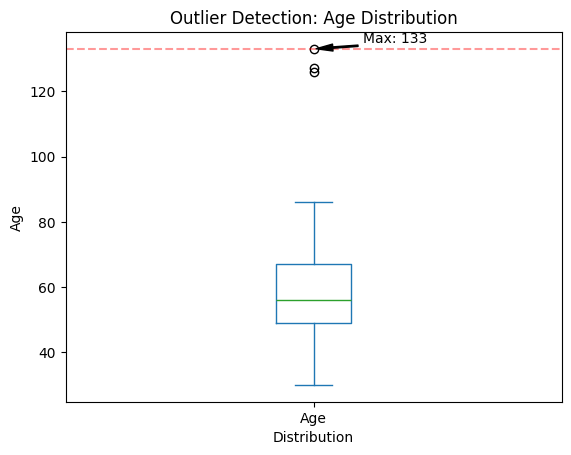

In [25]:
max_age = df['Age'].max()
df['Age'].plot(kind='box')
plt.ylabel('Age')
plt.xlabel('Distribution')
plt.annotate(f'Max: {max_age}',
             xy=(1, max_age),
             xytext=(1.1, max_age + 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.axhline(max_age, color='red', linestyle='--', alpha=0.4)
plt.title('Outlier Detection: Age Distribution')
plt.ylabel('Age')
plt.show()

__The boxplot shows clear outliers. Let's plot the column in descending order below__

In [27]:
df['Age'].sort_values(ascending=False).to_frame()

,Age
239,133
339,127
192,126
1950,86
424,85
...,...
696,31
747,31
995,31
1170,30


__There are three clear outliers. Let's list them, analise their data regarding Income, and their behavior__

In [29]:
age_outlier_idxes = list(df.query('Age>=123').index)
print('Age outliter indexes: ', age_outlier_idxes)
display(df.query('Age>=123')) 

Age outliter indexes:  [192, 239, 339]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Highest_Spent,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,0,65,Gold,126
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,0,22,Wines,133
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,0,1853,Wines,127


In [30]:
for idx in age_outlier_idxes:
    print('ID', df.loc[idx]['ID'])
    print('Age:', df.loc[idx]['Age'])
    print(f"Total Spent: {df.loc[idx]['Total_Spent']} x Average Spent: {df['Total_Spent'].mean():.2f}")
    print('=='*45)

ID 7829
Age: 126
Total Spent: 65 x Average Spent: 605.80
ID 11004
Age: 133
Total Spent: 22 x Average Spent: 605.80
ID 1150
Age: 127
Total Spent: 1853 x Average Spent: 605.80


### Visualizing Age Distribution Without Outliers
To assess the true demographic profile of the customer base, we will visualize the Age distribution after removing the identified extreme outliers (IDs `7829`, `11004`, and `1150`). This allows us to confirm if the remaining data follows a more natural distribution suitable for clustering and modeling.

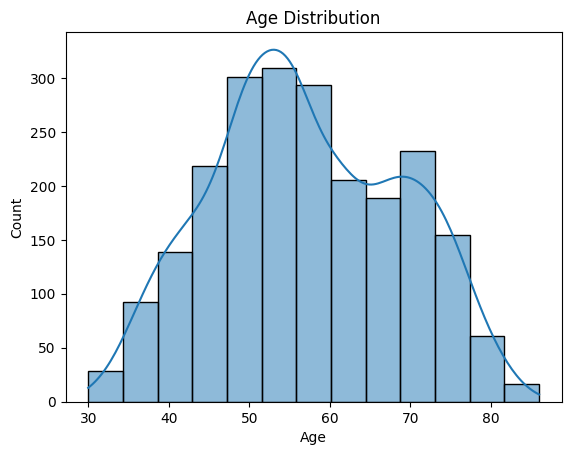

In [32]:
age_series = df['Age'].drop(age_outlier_idxes, axis=0)
n = len(age_series)
sturges_bins = int(np.ceil(1 + np.log2(n)))
sns.histplot(age_series, bins=sturges_bins, stat='count', kde=True)
plt.title('Age Distribution')
plt.show()

As observed, removing the extreme outliers has successfully normalized the Age distribution, centering the customer base around a more realistic demographic mean. By neutralizing the skew caused by impossible age values, we have stabilized the feature's variance, ensuring that the column now provides a clean, reliable signal for subsequent clustering and classification tasks.

To maintain the integrity of our clustering and predictive analysis, we are performing a targeted outlier treatment for biologically improbable age values (`>120`).
- Records `192` and `239` (IDs `7829` and `1150`): These will be dropped entirely. Their impossible ages combined with negligible spending suggest corrupted "ghost" data that provides no predictive value.
-  Customer `ID 1150`: We will retain this record but replace the age with the mean of the population. Since this customer is active, this preserves a valuable behavioral signal while neutralizing the statistical skew.
Because this issue affects < 0.1\% of the dataset, mean imputation is a robust choice that saves a perfectly good row of transactional data without significantly altering the feature's variance.

In [35]:
df.drop([192,239], axis=0, inplace=True)

In [36]:
age_mean = int(age_series.mean())
print(f"Customers' average age: {age_mean}")

Customers' average age: 57


__Let's now verify the new value of Client 1150__

In [38]:
df.at[339, 'Age'] = age_mean
print(f"Client {df.at[339, 'ID']} new age is now {df.at[339, 'Age']}")

Client 1150 new age is now 57


__Let's analyse the column <code>Age</code> and plot a boxplot__

In [40]:
print(f"The maximum age of our customers is {df['Age'].max()} years old, our youngest customer is {df['Age'].min()} years old and the average age is {df['Age'].mean():.2f} and the age median is {df['Age'].median()}")

The maximum age of our customers is 86 years old, our youngest customer is 30 years old and the average age is 57.10 and the age median is 56.0


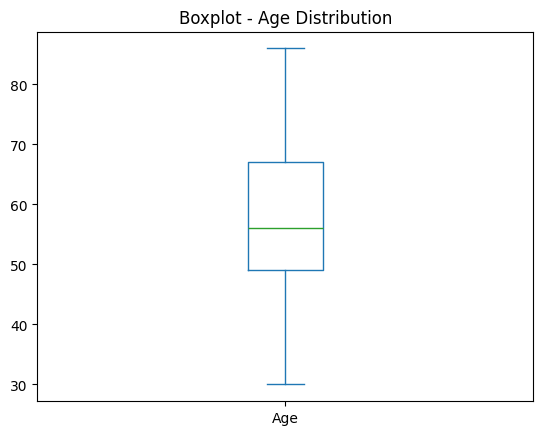

In [41]:
df['Age'].plot(kind='box')
plt.title('Boxplot - Age Distribution')
plt.show()

__Visually, everything is order. Let's just see the values of the youngest customers to make sure that are legitimate observations and not measurement errors, like the previous ones already treated above__

In [43]:
df['Age'].sort_values(ascending = False).head(20).to_frame()

,Age
1950,86
424,85
1923,83
358,83
894,83
2084,83
1150,83
39,83
415,83
1413,82


__And after all this cleaning, one question pops up: Are <code>Age</code> and <code>Income</code> correlated? Let's find out below.__

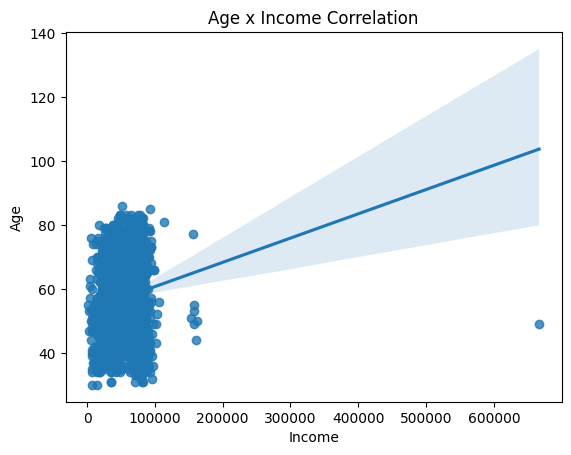

In [45]:
sns.regplot(data=df, x = 'Income', y = 'Age' )
plt.title('Age x Income Correlation')
plt.show()

The correlation analysis is currently skewed by an extreme `Income` outlier. This single observation is exerting disproportionate leverage on the regression slope, masking the actual relationship between age and purchasing power for the remaining `99.9%` of the dataset. Furthermore, as identified in our initial data check, `Income` is the only feature containing null values. Given these two distinct issues—statistical noise from an extreme outlier and missing information—we will conduct a deeper investigation into this column to ensure our eventual imputation and cleaning strategies are based on a representative distribution of the customer base.

In [47]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spent,Highest_Spent,Age
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,0,19,Meat,43
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,0,637,Gold,40
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,0,186,Wines,67
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,0,124,Wines,75
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,0,46,Meat,44
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,0,109,Meat,53
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,0,603,Wines,69
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,0,18,Meat,69
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,0,985,Wines,53
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,0,404,Wines,65


## `Income` boxplot

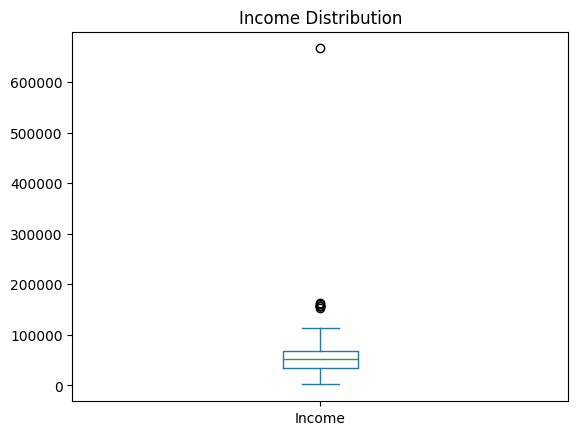

In [49]:
df['Income'].plot(kind='box')
plt.title('Income Distribution')
plt.show()

In [50]:
income_outlier = df['Income'].max()
income_outlier_record = df.iloc[df['Income']==income_outlier].index
df.drop(income_outlier_record, axis=0, inplace = True)
if income_outlier not in df.index:
    print('Outlier removed')

Outlier removed


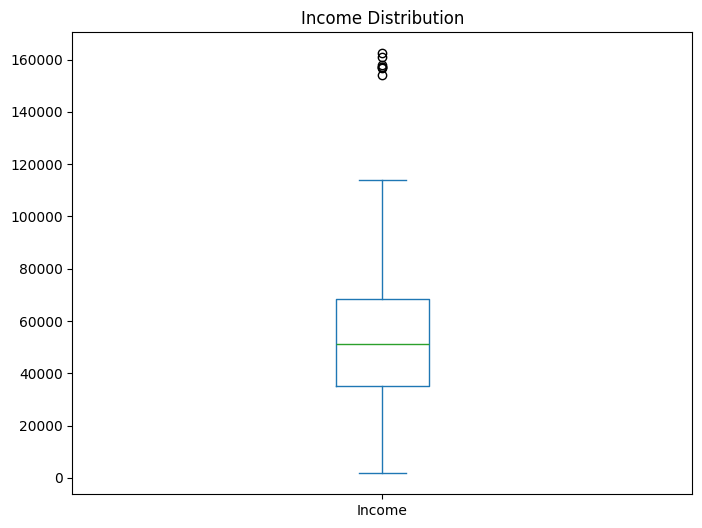

In [51]:
plt.figure(figsize=(8,6))
df['Income'].plot(kind='box')
plt.title('Income Distribution')
plt.show()

<Axes: xlabel='Income', ylabel='Count'>

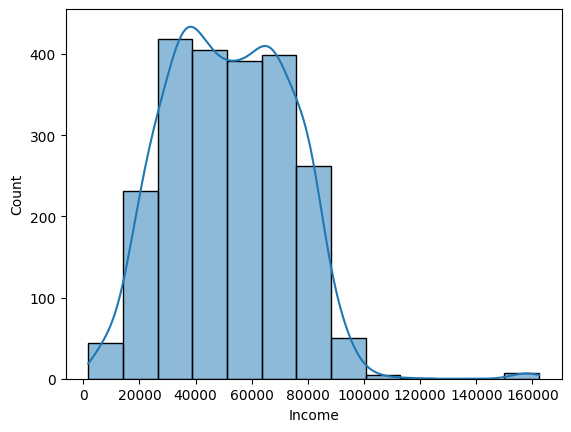

In [52]:
n = len(df['Income'].dropna())
sturges_bins = int(np.ceil(1 + np.log2(n)))
sns.histplot(df.dropna(), x='Income', bins = sturges_bins, kde=True)

In [53]:
print(f"Average Income: {round(df['Income'].mean(),2)}")
print(f"Income Median: {round(df['Income'].median(),2)}")
print(f"Income Standard Deviation: {round(df['Income'].std(),2)}")

Average Income: 51973.08
Income Median: 51373.0
Income Standard Deviation: 21532.87


Since the removal of extreme outliers has restored a near-normal distribution to the `Income` feature, we will impute missing values using the median. This is a robust choice that preserves the central tendency of the data while remaining resistant to any residual skewness, ensuring the statistical integrity of the feature is maintained for both clustering and classification models.

In [55]:
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(round(income_median,2)) 
print(f"Average Income: {round(df['Income'].mean(),2)}")
print(f"Income Median: {round(df['Income'].median(),2)}")
print(f"Income Standard Deviation: {round(df['Income'].std(),2)}")
print(df['Income'].isnull().sum())

Average Income: 51966.64
Income Median: 51373.0
Income Standard Deviation: 21417.09
0


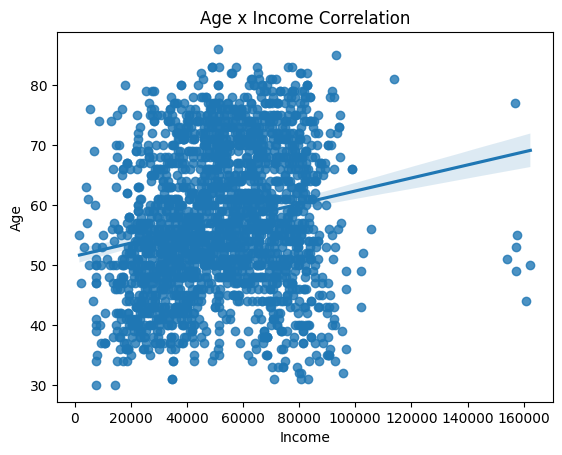

In [56]:
sns.regplot(data=df, x = 'Income', y = 'Age' )
plt.title('Age x Income Correlation')
plt.show()

Even after treating the outliers and imputing missing values, the regression analysis confirms there is no significant linear correlation between Age and Income. The dense cluster of data points across all age groups suggests that in this specific market, purchasing power is not a function of seniority or life stage. This is a critical finding for our upcoming modeling phase; it indicates that these two features provide independent information, and we should look toward other variables—such as marital status, education level or household composition—to explain the variance in customer spending behavior.

__Let's analise another fundamental aspect for customers' behavior: their _Marital Status_. Further on, we will find how the household composition impacts the customers' choices.__ 

__What are the _Marital Statuses_ on our dataset?__

In [59]:
for i in df['Marital_Status'].unique():
    print(i)

Single
Together
Married
Divorced
Widow
Alone
Absurd
YOLO


__<code>Alone</code>, <code>Absurd</code> and <code>YOLO</code> are not exactly conventional _Marital Statuses_. Let's now analise the absolute and relative frequency of these categorical values__

In [61]:
frequency= df['Marital_Status'].value_counts()
percentages = round((df['Marital_Status'].value_counts(normalize=True) * 100),2)
freq_marital = pd.DataFrame({'Frequency':frequency, 'Percentages (%)': percentages})
freq_marital

,Frequency,Percentages (%)
Marital_Status,,
Married,864,38.62
Together,579,25.88
Single,479,21.41
Divorced,231,10.33
Widow,77,3.44
Alone,3,0.13
Absurd,2,0.09
YOLO,2,0.09


__Now, let's see the absolute and relative frequency of <code>Education</code>__

In [63]:
frequency_education= df['Education'].value_counts()
percentages_education = round((df['Education'].value_counts(normalize=True) * 100),2)
freq_education = pd.DataFrame({'Frequency':frequency_education, 'Percentages (%)': percentages_education})
freq_education.index.name='Education'
freq_education

,Frequency,Percentages (%)
Education,,
Graduation,1126,50.34
PhD,486,21.73
Master,370,16.54
2n Cycle,201,8.99
Basic,54,2.41


__Now, let's cross-tabulate <code>Education</code> and <code>Marital_Status</code>. We will create two tables. One with the absolute frequency and another one with the relative frequency.__

In [65]:
# Absolute frequency
ct = pd.crosstab(df['Education'], df['Marital_Status'])
# Relative frequency (percentage of total)
ct_pct = round(pd.crosstab(df['Education'], df['Marital_Status'], normalize='all') * 100,2) 

In [66]:
print('Relative frequency')
ct_pct

Relative frequency


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,0.00,0.00,0.98,3.62,1.61,2.55,0.22,0.00
Basic,0.00,0.00,0.04,0.89,0.80,0.63,0.04,0.00
Graduation,0.04,0.04,5.32,19.36,11.27,12.74,1.56,0.00
Master,0.04,0.04,1.65,6.17,3.35,4.74,0.54,0.00
PhD,0.00,0.04,2.32,8.58,4.38,5.23,1.07,0.09


In [67]:
print('Absolute Frequency')
ct

Absolute Frequency


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,0,0,22,81,36,57,5,0
Basic,0,0,1,20,18,14,1,0
Graduation,1,1,119,433,252,285,35,0
Master,1,1,37,138,75,106,12,0
PhD,0,1,52,192,98,117,24,2


Cross-tabulating `Education` and `Marital_Status` reveals that non-standard entries like `Absurd` and  `YOLO` are statistically insignificant noise, appearing in less than 0.1% of the population. To streamline our feature engineering and prevent model overfitting on these rare categories, we will consolidate `Alone`, `Absurd`, and `YOLO`into the `Single` category.

In [69]:
df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')
print(df['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


In [70]:
ct = pd.crosstab(df['Education'], df['Marital_Status'])
ct_pct = round(pd.crosstab(df['Education'], df['Marital_Status'], normalize='all') * 100,2) 

In [71]:
import plotly.graph_objects as go

# 1. Prepare data (ensure columns are the marital statuses)
# ct_pct should have Education as index and Marital Statuses as columns
categories = ct_pct.index.tolist()  # Education levels
status_cols = ct_pct.columns.tolist()  # Marital Statuses

fig = go.Figure()

# 2. Add a trace for each Education level (initially only the first one is visible)
for i, edu in enumerate(categories):
    fig.add_trace(
        go.Bar(
            x=status_cols,
            y=ct_pct.loc[edu],
            name=edu,
            visible=(i == 0), # Only first education level shown by default
            text=[f"{v:.2f}%" for v in ct_pct.loc[edu]],
            textposition='auto',
        )
    )

# 3. Create the dropdown menu
dropdown_buttons = []
for i, edu in enumerate(categories):
    # Create a list of booleans: True for the current trace, False for others
    visibility = [False] * len(categories)
    visibility[i] = True
    
    dropdown_buttons.append(dict(
        label=edu,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Marital Status Breakdown for {edu}"}]
    ))

# 4. Update layout with the menu
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=dropdown_buttons,
        direction="down",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.1,
        xanchor="left",
        y=1.15,
        yanchor="top"
    )],
    title=f"Marital Status Breakdown for {categories[0]}",
    yaxis_title="Percentage (%)",
    template="plotly_white",
    height=500
)

fig.show()

__So far we know that <code>50.34%</code> of our customers are graduated. Most of our customers are also married and when we cross-tabulate <code>Education</code> and <code>Marital_Status</code> we can see the pattern showing again.__

__Further along the analysis, we will find out how <code>Income</code> <code>Education</code> and <code>Marital_status</code> reflect on the buying habits of our clients__

In [73]:
avg_age = round(df.groupby("Marital_Status")['Age'].mean().to_frame(),2) 
avg_age.rename(columns ={'Age':'Average Age'}, inplace=True)
avg_age.index.name='Marital Status'
avg_age

,Average Age
Marital Status,
Divorced,59.44
Married,56.42
Single,54.32
Together,58.15
Widow,67.44


__Let's group the our customers by marital status and than see the percentages of total purchases__

In [120]:
purchase_channels = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_channels].sum(axis=1)
total_global_volume = df['Total_Purchases'].sum()

In [122]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Total_Spent', 'Highest_Spent',
       'Age', 'Total_Purchases'],
      dtype='str')

In [124]:
grouped_data = df.groupby('Marital_Status')['Total_Purchases'].sum()*100/total_global_volume
grouped_data

Marital_Status
Divorced    10.607154
Married     38.839796
Single      20.889690
Together    25.798016
Widow        3.865344
Name: Total_Purchases, dtype: float64

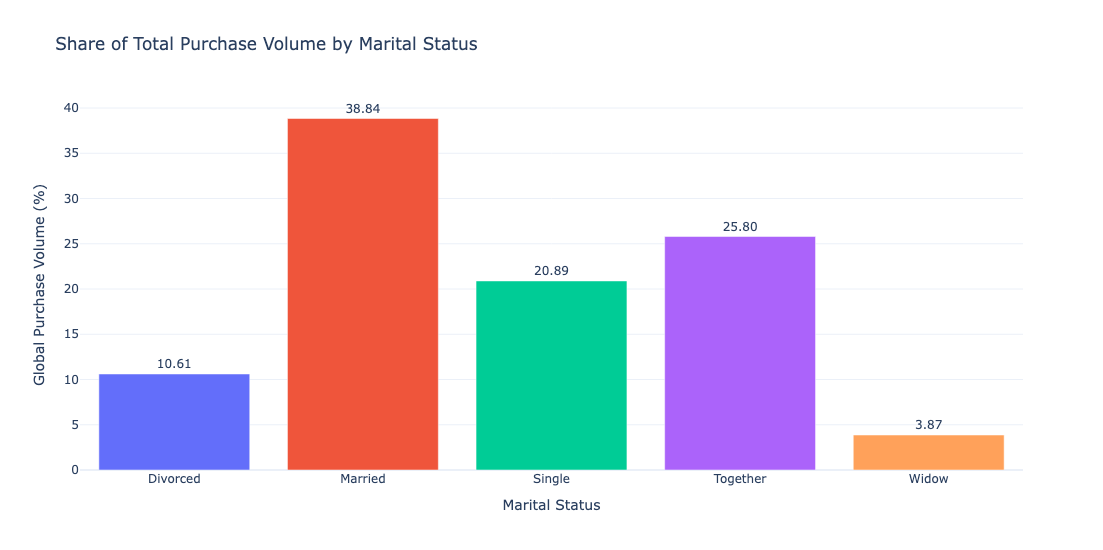

In [126]:
df_volume = grouped_data.reset_index()
fig = px.bar(df_volume, 
             x='Marital_Status', 
             y='Total_Purchases',
             color='Marital_Status', # Automatically applies a distinct color palette
             title='Share of Total Purchase Volume by Marital Status',
             labels={'Total_Purchases': 'Global Purchase Volume (%)', 'Marital_Status': 'Marital Status'},
             template='plotly_white',
             text_auto='.2f' # Shows percentages on top of bars
            )

# 3. Polish the layout
fig.update_layout(showlegend=False, height=550)
fig.update_traces(textposition='outside')

fig.show()

__Married people are the majority of our customers, so it's no surprise that they highest percentage of purchases is theirs. Still, there must be more to extract from our data.__ 

__For example, in average, who makes more money, according to marital status?__

In [137]:
round(df.groupby('Marital_Status')['Income'].mean().sort_values(ascending=False).to_frame(),2).reset_index().sort_values(by='Income', ascending=False)

,Marital_Status,Income
0,Widow,56415.21
1,Divorced,52904.33
2,Together,52163.45
3,Married,51722.13
4,Single,51016.35


In [139]:
widows_avg_income = df[df['Marital_Status']=='Widow']['Income'].mean()
avg_income = df['Income'].mean()
income_diff = (widows_avg_income - avg_income)/avg_income * 100
print(f"The average income of our whole customers database is {avg_income:.2f} while widows income is in average: {widows_avg_income:.2f}, making it {income_diff:.2f}% higher the total average")


The average income of our whole customers database is 51966.64 while widows income is in average: 56415.21, making it 8.56% higher the total average


__Widows, as we can see above, make in average 8.5% more money than the total average of our customers. That's interesting.__

__Now, let's group by <code>Marital_Status</code> and <code>Education</code> and see the average <code>Incoming</code> of each group of customers__

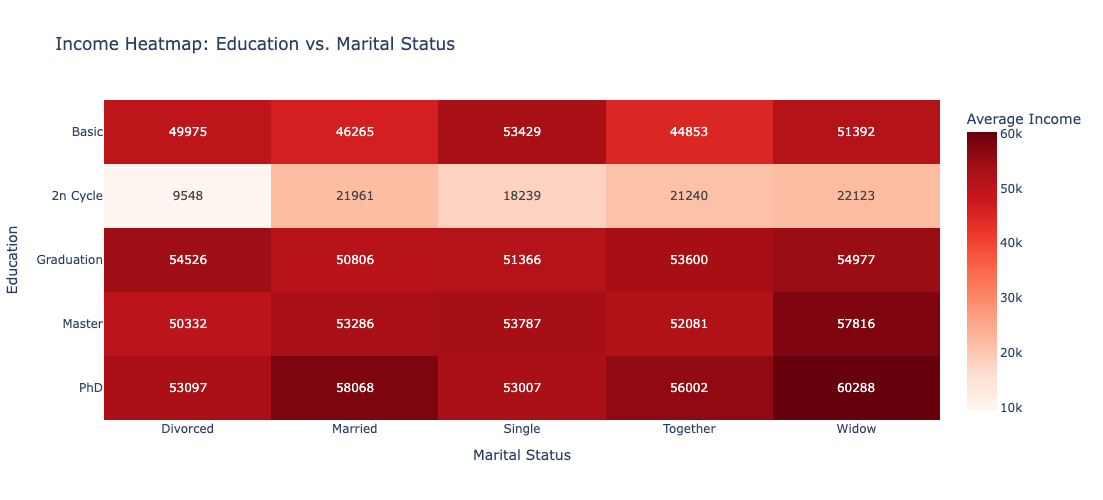

In [156]:
heatmap_data = df.groupby(['Education', 'Marital_Status'])['Income'].mean().reset_index()

fig = px.imshow(
    heatmap_data.pivot(index='Education', columns='Marital_Status', values='Income'),
    labels=dict(x="Marital Status", y="Education", color="Average Income"),
    x=['Divorced', 'Married', 'Single', 'Together', 'Widow'],
    y=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'],
    aspect="auto",
    color_continuous_scale='Reds',
    title='Income Heatmap: Education vs. Marital Status',
    text_auto='.0f'
)

fig.update_layout(height=500, template='plotly_white')
fig.show()

__Widows with PhD the highest Incomes, followed by married people with PhD.__ 

__We also have the information that most of the customers are married and graduate. How do these differences reflect in their buying habits? We will start by displaying the total sum of their purchases by education and marital status__

In [224]:
cat_data = round(df.groupby(['Education', 'Marital_Status', 'Highest_Spent']).agg({
    'Total_Spent':'mean',
    'Total_Purchases': 'mean'}
),2).reset_index()

In [230]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)

# 1. Layout with two dropdowns
app.layout = html.Div([
    html.H2("Segmented Spending Explorer"),
    
    html.Div([
        html.Div([
            html.Label("Education:"),
            dcc.Dropdown(
                id='edu-dropdown',
                options=[{'label': i, 'value': i} for i in cat_data['Education'].unique()],
                value=cat_data['Education'].unique()[0],
                clearable=False
            )
        ], style={'width': '48%', 'display': 'inline-block'}),

        html.Div([
            html.Label("Marital Status:"),
            dcc.Dropdown(
                id='marital-dropdown',
                options=[{'label': i, 'value': i} for i in cat_data['Marital_Status'].unique()],
                value=cat_data['Marital_Status'].unique()[0],
                clearable=False
            )
        ], style={'width': '48%', 'float': 'right', 'display': 'inline-block'})
    ], style={'padding': '20px'}),

    dcc.Graph(id='final-bar-plot')
])

# 2. Callback listening to BOTH inputs
@app.callback(
    Output('final-bar-plot', 'figure'),
    [Input('edu-dropdown', 'value'),
     Input('marital-dropdown', 'value')]
)
def update_graph(selected_edu, selected_marital):
    # Filter by both selectors
    filtered_df = cat_data[
        (cat_data['Education'] == selected_edu) & 
        (cat_data['Marital_Status'] == selected_marital)
    ]
    
    # Since we are filtered down to specific products, a Bar chart is clearer than a Treemap
    fig = px.bar(
        filtered_df,
        x='Highest_Spent',
        y='Total_Purchases',
        color='Total_Spent',
        color_continuous_scale='RdBu',
        text_auto='.2f',
        title=f"Spending for {selected_edu}s who are {selected_marital}",
        labels={'Total_Spent': 'Avg Spent', 'Total_Purchases': 'Avg Purchases'}
    )
    
    fig.update_layout(template='plotly_white', height=500)
    return fig

app.run_server(mode='inline', port=8051)

In [238]:
print(f"Average Income for Widows with PhD: {df[(df['Marital_Status'] == 'Widow') & (df['Education'] == 'PhD')]['Income'].mean():.2f}")
print(f"Average Income for Widows with a Master's Degree: {df[(df['Marital_Status'] == 'Widow') & (df['Education'] == 'Master')]['Income'].mean():.2f}")
print(f"Average Customers' Income: {df['Income'].mean():.2f}")
print(f"Income Standard Deviation for Widows with PhD: {df[(df['Marital_Status'] == 'Widow') & (df['Education'] == 'PhD')]['Income'].std():.2f}")
print(f"Income Standard Deviation for Widows with a Master's Degree: {df[(df['Marital_Status'] == 'Widow') & (df['Education'] == 'Master')]['Income'].std():.2f}")
print(f"Customers' Income Standard Deviation: {df['Income'].std():.2f}")

Average Income for Widows with PhD: 60288.08
Average Income for Widows with a Master's Degree: 57815.83
Average Customers' Income: 51966.64
Income Standard Deviation for Widows with PhD: 16030.90
Income Standard Deviation for Widows with a Master's Degree: 15769.15
Customers' Income Standard Deviation: 21417.09


__Not only their average income is higher, they also have lower standard deviation values for income, which means that we can offer higher end products to this audience, once they earn more and are less price sensitive__

In [247]:
#plt.figure(figsize=(20,20))
fig = px.imshow(df.corr(), text_auto=True, title='Correlation Matrix')
fig.update_layout(height=900, width=900)
fig.show()

ValueError: could not convert string to float: 'Graduation'

__We have some interesting findings, analising the correlation matrix:__ 

- Meat Products and Wine Products are more have higher correlation with Income than Gold Products. People who earn more tend to spend more money with food and drink and not with gold products.
- Catalog Purchases and Meat Products have high correlation just like Catalog Purchases and Wine, and Catalog Purchases and Income. 
- Number of kids at home is correlated to the number of visits on the website a month
- Number of teens at home is correlated to number of purchases with discount 

__Now we will create separate dataframes for customers by marital status and analise their buying habits__ 

In [ ]:
df_single = df[df['Marital_Status']=='Single']
df_married = df[df['Marital_Status']=='Married']
df_divorced = df[df['Marital_Status']=='Divorced']
df_widow = df[df['Marital_Status']=='Widow']
df_together = df[df['Marital_Status']=='Together']

__Let's analise the total purchases of each product by marital status__

In [ ]:
single_products=df_single[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()
married_products=df_married[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()
together_products=df_together[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()
widow_products=df_widow[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()
divorced_products=df_divorced[['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()

x = list(range(len(single_products)))
plt.figure(figsize= (12, 8)) 
plt.bar([i - 0.3 for i in x], single_products.values, label='Singles', width=0.1)
plt.bar([i - 0.2 for i in x], married_products.values, label='Married', width=0.1)
plt.bar([i - 0.1 for i in x] , together_products.values, label='Together', width = 0.1)
plt.bar([i  for i in x] , widow_products.values, label='Widows', width = 0.1)
plt.bar([i + 0.1 for i in x] , divorced_products.values, label='Divorced', width = 0.1)
plt.xticks([i for i in range(6)],['Wines', 'Fruits', 'Meat Products', 'Fish Products', 'Sweet Products', 'Gold Products'])



plt.legend()
plt.show()

__Married people at top, but you can clearly see the expressive participation of widows in total purchases of Wine and Meat Products__

__What purchase channels do our customers use the most? Who is more price sensitive and tend to make purchases with discounts?__ 

__To set an accurate comparison, we will use both relative and absolute values, in order to have better and more fruitful insights__ 

In [ ]:
fig = plt.figure(figsize=(24,12))

ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

avg_single_habits=df_single[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].mean()
avg_married_habits=df_married[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].mean()
avg_together_habits=df_together[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].mean()
avg_widow_habits=df_widow[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].mean()
avg_divorced_habits=df_divorced[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].mean()

single_habits=df_single[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
married_habits=df_married[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
together_habits=df_together[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
widow_habits=df_widow[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
divorced_habits=df_divorced[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()


x = list(range(len(single_habits)))
#ax0.figure(figsize=(12,8))
ax0.bar([i-0.3 for i in x], avg_single_habits.values, label= 'Singles', width = 0.1)
ax0.bar([i-0.2 for i in x], avg_married_habits.values, label= 'Married', width = 0.1)
ax0.bar([i-0.1 for i in x], avg_together_habits.values, label= 'Together', width = 0.1)
ax0.bar([i for i in x], avg_widow_habits.values, label= 'Widows', width = 0.1)
ax0.bar([i + 0.1 for i in x], avg_divorced_habits.values, label= 'Divorced', width = 0.1)
ax0.set_xticks([i for i in range(5)],['Purchases with discount', 'Web Purchases', 'Catalog Purchases', 'Store Purchases', 'Web Visits'])
ax0.set_title('Customers purchase habits - Relative Comparison')

x = list(range(len(single_habits)))
#ax0.figure(figsize=(12,8))
ax1.bar([i-0.3 for i in x], single_habits.values, label= 'Singles', width = 0.1)
ax1.bar([i-0.2 for i in x], married_habits.values, label= 'Married', width = 0.1)
ax1.bar([i-0.1 for i in x], together_habits.values, label= 'Together', width = 0.1)
ax1.bar([i for i in x], widow_habits.values, label= 'Widows', width = 0.1)
ax1.bar([i + 0.1 for i in x], divorced_habits.values, label= 'Divorced', width = 0.1)
ax1.set_xticks([i for i in range(5)],['Purchases with discount', 'Web Purchases', 'Catalog Purchases', 'Store Purchases', 'Web Visits'])
ax1.set_title('Customers purchase habits - Absolute Values')

plt.legend()
plt.show()



__In absolute values, once again, married people are unbeatable and purchase more than the other groups in every purchase channel. Yet, when we compare the relative values, we confirm that widows are shown to be a very promising group of customers. They are older, their average buying ticket is higher and they prefer store purchases, which can lead to effective marketing strategies alligned with their habits, such as a special wine selection for store and catalog customers or even a special guide on how to harmonize wines and meat, the two products they buy the most__ 